## FiTech: Data Driven Credit Card Design

* Team-lead GitHub userid: rsm-xyz123
* Group name:
* Team member names:
    - Hargun Kohli
    - Krithika Suwarna
    - Siddhartha Mysore
    - Vidhi Vashisth

## Setup

Please complete this python notebook with your group by answering the questions in `fitech-msba.pdf`.

Create a Notebook with all your results and comments and push the Notebook to GitHub when your team is done. Make sure to connect the GitHub repo to GradeScope before the due date. All results MUST be reproducible (i.e., the TA and I must be able to recreate your output from the Jupyter Notebook without changes or errors). This means that you should NOT use any python-packages that are not part of the RSM-MSBA docker container.

> Note: Please do not install any packages as part of your Jupyter Notebook submission

This is a group assignment and you will be using Git and GitHub. If two people edit the same file at the same time you could get what is called a "merge conflict". This is not something serious but you should realize that Git will not decide for you who's changes to accept. The team-lead will have to determine the edits to use. To avoid merge conflicts, **always** "pull" changes to the repo before you start working on any files. Then, when you are done, save and commit your changes, and then push them to GitHub. Make "pull first" a habit!

If multiple people are going to work on the assignment at the same time I recommend you work in different notebooks. You can then `%run ...`  these "sub" notebooks from the main assignment file. You can seen an example of this in action below for the `model1.ipynb` notebook

Some group work-flow tips:

* Pull, edit, save, stage, commit, and push
* Schedule who does what and when
* Try to avoid working simultaneously on the same file
* If you are going to work simultaneously, do it in different notebooks, e.g.,
    - model1.ipynb, question1.ipynb, etc.
* Use the `%run ... ` command to bring different pieces of code together into the main jupyter notebook
* Put python functions in modules that you can import from your notebooks. See the example below for the `example` function defined in `utils/functions.py`

A graphical depiction of the group work-flow is shown below:

![](images/github-group-workflow.png)

In [74]:
import pandas as pd
import pyrsm as rsm

## Question answers

In [75]:
data_df = pd.read_excel(
    "data/exhibits.xlsx",
    sheet_name = "exhibit1",
    )
data_df

,date,apr,fixed_var,annual_fee,visamc,nr_mailed,non_resp,resp,bk_score
0,April,16.8,Fixed,20,MC,167000,165467,1533,200
1,April,16.8,Fixed,0,MC,81000,78104,2896,200
2,April,19.8,Fixed,20,MC,143000,142410,590,200
3,April,19.8,Fixed,0,MC,100000,97948,2052,200
4,September,14.9,Fixed,20,Visa,177000,172671,4329,250
5,September,14.9,Variable,20,Visa,170000,166996,3004,250
6,September,16.8,Fixed,20,Visa,255000,252017,2983,250
7,September,19.8,Fixed,20,Visa,35000,34825,175,250
8,September,16.8,Fixed,0,Visa,65000,62484,2516,250
9,September,19.8,Fixed,0,Visa,95000,92885,2115,250


In [76]:
data_df.dtypes

date           object
apr           float64
fixed_var      object
annual_fee      int64
visamc         object
nr_mailed       int64
non_resp        int64
resp            int64
bk_score        int64
dtype: object

Convert Data types to Category

In [77]:
data_df['apr'] = data_df['apr'].astype('category')
data_df['fixed_var'] = data_df['fixed_var'].astype('category')
data_df['annual_fee'] = data_df['annual_fee'].astype('category')
data_df['bk_socre'] = data_df['bk_score'].astype('category')
data_df['date'] = data_df['date'].astype('category')
data_df.dtypes

date          category
apr           category
fixed_var     category
annual_fee    category
visamc          object
nr_mailed        int64
non_resp         int64
resp             int64
bk_score         int64
bk_socre      category
dtype: object

In [78]:
data_df2 = pd.read_excel(
    "data/exhibits.xlsx",
    sheet_name = "exhibit2",
    )
data_df2

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250
0,1,14.9,Fixed,20,83,63,33
1,2,14.9,Variable,20,93,73,43
2,3,14.9,Fixed,0,52,32,2
3,4,14.9,Variable,0,62,42,12
4,5,16.8,Fixed,20,103,83,53
5,6,16.8,Variable,20,113,93,63
6,7,16.8,Fixed,0,72,52,22
7,8,16.8,Variable,0,82,62,32
8,9,19.8,Fixed,20,131,111,81
9,10,19.8,Variable,20,141,121,91


In [79]:
total_freq = data_df['nr_mailed'].sum()
total_freq

1520000

Cross tabs

In [80]:
ct = rsm.basics.cross_tabs({"data_df": data_df},"apr", "fixed_var")
ct.summary()


Cross-tabs
Data     : data_df
Variables: apr, fixed_var
Null hyp : There is no association between apr and fixed_var
Alt. hyp : There is an association between apr and fixed_var

Observed:

fixed_var Fixed Variable Total
apr                           
14.9          3        2     5
16.8          5        0     5
19.8          4        0     4
Total        12        2    14

Expected: (row total x column total) / total

fixed_var Fixed Variable Total
apr                           
14.9       4.29     0.71   5.0
16.8       4.29     0.71   5.0
19.8       3.43     0.57   4.0
Total      12.0      2.0  14.0

Chi-squared: 4.2 df(2), p.value 0.12
67.0% of cells have expected values below 5



#### Melting Data

In [81]:
data_df_melt = pd.melt(
    data_df,
    id_vars = ["date", "apr", "fixed_var", "visamc", "annual_fee", "nr_mailed", "bk_score"],
    value_vars = ["resp", "non_resp"],
    var_name = "resp",
    value_name = "freq",
    )
data_df_melt

,date,apr,fixed_var,visamc,annual_fee,nr_mailed,bk_score,resp,freq
0,April,16.8,Fixed,MC,20,167000,200,resp,1533
1,April,16.8,Fixed,MC,0,81000,200,resp,2896
2,April,19.8,Fixed,MC,20,143000,200,resp,590
3,April,19.8,Fixed,MC,0,100000,200,resp,2052
4,September,14.9,Fixed,Visa,20,177000,250,resp,4329
5,September,14.9,Variable,Visa,20,170000,250,resp,3004
6,September,16.8,Fixed,Visa,20,255000,250,resp,2983
7,September,19.8,Fixed,Visa,20,35000,250,resp,175
8,September,16.8,Fixed,Visa,0,65000,250,resp,2516
9,September,19.8,Fixed,Visa,0,95000,250,resp,2115


In [82]:
data_df_melt.dtypes

date          category
apr           category
fixed_var     category
visamc          object
annual_fee    category
nr_mailed        int64
bk_score         int64
resp            object
freq             int64
dtype: object

In [83]:
total_freq = data_df_melt['freq'].sum()
total_freq

1520000

In [84]:
data_full = rsm.table2data(data_df_melt,"freq")
data_full

,date,apr,fixed_var,visamc,annual_fee,nr_mailed,bk_score,resp,freq
0,April,16.8,Fixed,MC,20,167000,200,resp,1533
0,April,16.8,Fixed,MC,20,167000,200,resp,1533
0,April,16.8,Fixed,MC,20,167000,200,resp,1533
0,April,16.8,Fixed,MC,20,167000,200,resp,1533
0,April,16.8,Fixed,MC,20,167000,200,resp,1533
...,...,...,...,...,...,...,...,...,...
27,November,16.8,Fixed,Visa,20,50000,150,non_resp,49627
27,November,16.8,Fixed,Visa,20,50000,150,non_resp,49627
27,November,16.8,Fixed,Visa,20,50000,150,non_resp,49627
27,November,16.8,Fixed,Visa,20,50000,150,non_resp,49627


### Logistic Regression Model

#### With huge dataset

In [85]:
lr = rsm.model.logistic(
    data ={"data_full": data_full},
    rvar = "resp", lev = "resp", evar = ["apr", "fixed_var", "annual_fee", "bk_score"],
)
lr.summary()

Logistic regression (GLM)
Data                 : data_full
Response variable    : resp
Level                : resp
Explanatory variables: apr, fixed_var, annual_fee, bk_score
Null hyp.: There is no effect of x on resp
Alt. hyp.: There is an effect of x on resp

                        OR     OR%  coefficient  std.error  z.value p.value     
Intercept            0.036  -96.4%        -3.31      0.035  -95.624  < .001  ***
apr[16.8]            0.480  -52.0%        -0.73      0.016  -46.404  < .001  ***
apr[19.8]            0.263  -73.7%        -1.34      0.020  -66.447  < .001  ***
fixed_var[Variable]  0.744  -25.6%        -0.30      0.021  -14.230  < .001  ***
annual_fee[20]       0.290  -71.0%        -1.24      0.015  -84.711  < .001  ***
bk_score             1.003    0.3%         0.00      0.000   19.817  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squared (McFadden): 0.033
Pseudo R-squared (McFadden adjusted): 0.033
Area under the RO Curve (AU

#### With the melted dataset

In [86]:
lr1 = rsm.model.logistic(
    data ={"tools_data_melt": data_df_melt},
    rvar = "resp", lev = "resp", evar = ["apr", "fixed_var", "annual_fee", "bk_score"],
    weights = "freq"
)
lr1.summary()

Logistic regression (GLM)


Data                 : tools_data_melt
Response variable    : resp
Level                : resp
Explanatory variables: apr, fixed_var, annual_fee, bk_score
Weights used         : freq
Null hyp.: There is no effect of x on resp
Alt. hyp.: There is an effect of x on resp

                        OR     OR%  coefficient  std.error  z.value p.value     
Intercept            0.036  -96.4%        -3.31      0.035  -95.624  < .001  ***
apr[16.8]            0.480  -52.0%        -0.73      0.016  -46.404  < .001  ***
apr[19.8]            0.263  -73.7%        -1.34      0.020  -66.447  < .001  ***
fixed_var[Variable]  0.744  -25.6%        -0.30      0.021  -14.230  < .001  ***
annual_fee[20]       0.290  -71.0%        -1.24      0.015  -84.711  < .001  ***
bk_score             1.003    0.3%         0.00      0.000   19.817  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squared (McFadden): 0.033
Pseudo R-squared (McFadden adjusted): 0.033
Area under the RO 

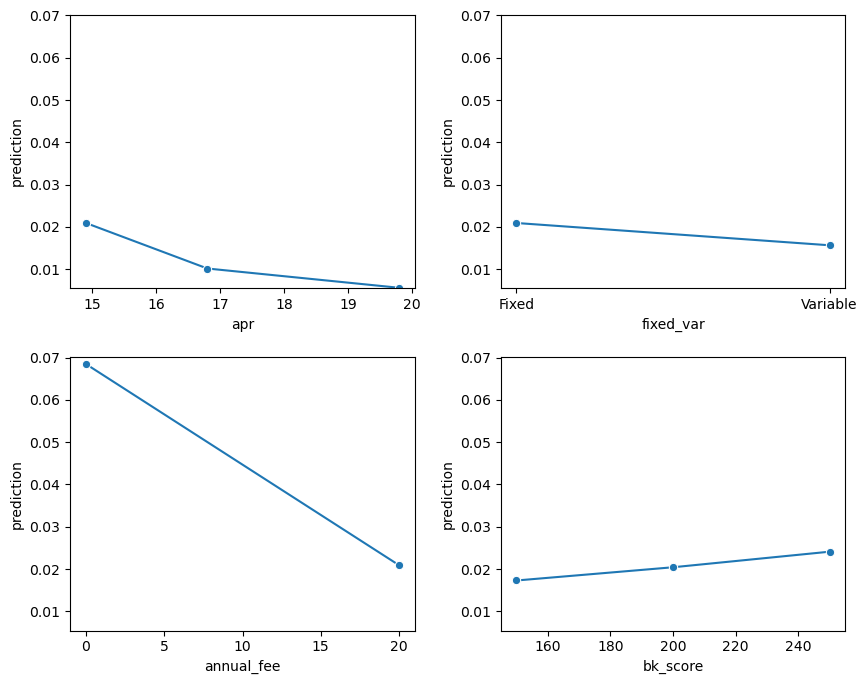

In [87]:
lr1.plot(plots="pred")

### Neural Network

In [88]:
base_nn = rsm.model.mlp(
        data={"Data_nn": data_full},
        rvar="resp",
        lev="resp",
        evar=["date", "apr", "fixed_var", "annual_fee", "bk_score" , "nr_mailed", "visamc"],
        alpha = 0.001,
        hidden_layer_sizes=(5,),
        mod_type="classification",
    )
base_nn.summary()

Multi-layer Perceptron (NN)
Data                 : Data_nn
Response variable    : resp
Level                : resp
Explanatory variables: date, apr, fixed_var, annual_fee, bk_score, nr_mailed, visamc
Model type           : classification
Nr. of features      : (7, 9)
Nr. of weights       : 50
Nr. of observations  : 1,520,000
Hidden_layer_sizes   : (5,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.663

Raw data             :
 date  apr fixed_var annual_fee  bk_score  nr_mailed visamc
April 16.8     Fixed         20       200     167000    MC 
April 16.8     Fixed         20       200     167000    MC 
April 16.8     Fixed         20       200     167000    MC 
April 16.8     Fixed         20       200     167000    MC 
April 16.8     Fixed         20       200     167000    MC 

Estimation data      :
 bk_sc

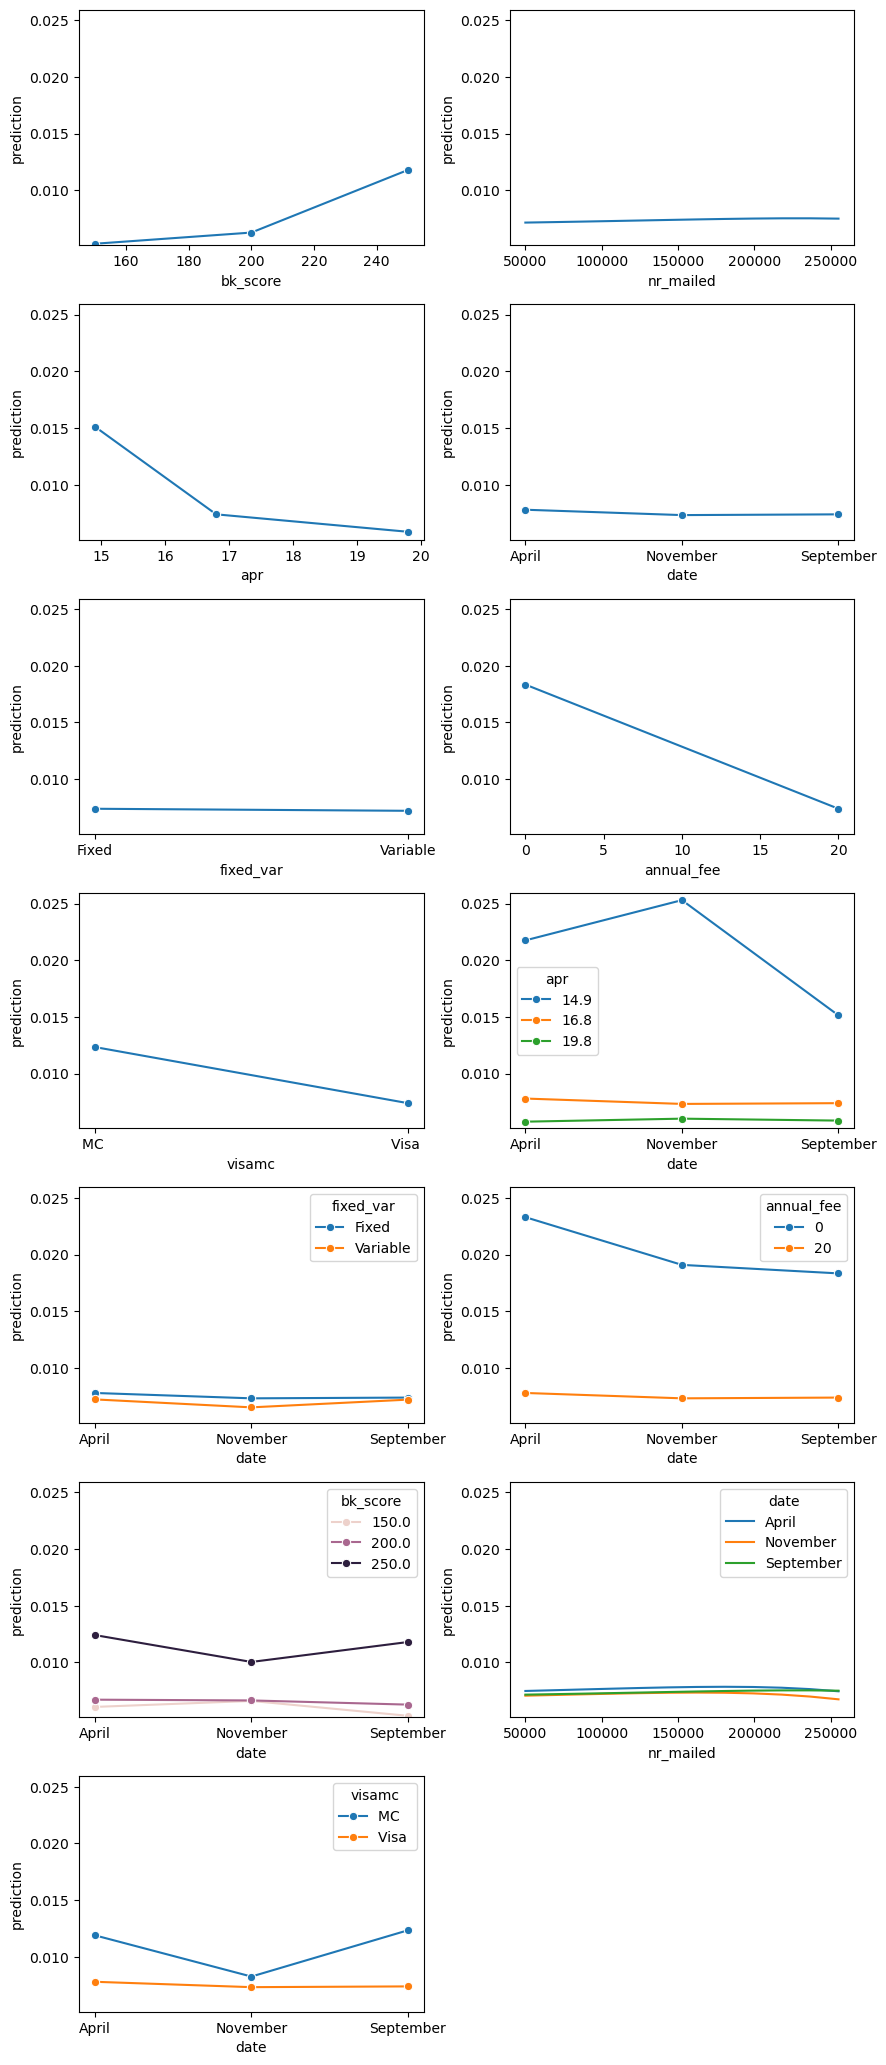

In [89]:
base_nn.plot(plots="pred", incl_int= ["date:apr", "date:fixed_var", "date:annual_fee", "date:bk_score", "date:nr_mailed", "date:visamc"])

### Data Expand

In [90]:
dct = rsm.levels_list(data_df_melt[["apr", "fixed_var", "annual_fee", "bk_score"]])
dct

{'apr': [16.8, 19.8, 14.9],
 'fixed_var': ['Fixed', 'Variable'],
 'annual_fee': [20, 0],
 'bk_score': [200, 250, 150]}

In [91]:
data_expand = rsm.expand_grid(dct)
data_expand

,apr,fixed_var,annual_fee,bk_score
0,16.8,Fixed,20,200
1,16.8,Fixed,20,250
2,16.8,Fixed,20,150
3,16.8,Fixed,0,200
4,16.8,Fixed,0,250
5,16.8,Fixed,0,150
6,16.8,Variable,20,200
7,16.8,Variable,20,250
8,16.8,Variable,20,150
9,16.8,Variable,0,200


#### Getting all the predictions

In [92]:
data_expand["pred_all"] = lr.predict(data_expand)["prediction"]
data_expand

,apr,fixed_var,annual_fee,bk_score,pred_all
0,16.8,Fixed,20,200,0.009897
1,16.8,Fixed,20,250,0.011705
2,16.8,Fixed,20,150,0.008366
3,16.8,Fixed,0,200,0.033292
4,16.8,Fixed,0,250,0.039205
5,16.8,Fixed,0,150,0.028244
6,16.8,Variable,20,200,0.007379
7,16.8,Variable,20,250,0.008732
8,16.8,Variable,20,150,0.006235
9,16.8,Variable,0,200,0.024973


#### Merge Exhibit 1 and Exhibit 2 data

In [93]:
new_table = pd.merge(data_df2, data_expand, on=['apr', 'fixed_var', 'annual_fee'], how='inner')
new_table

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all
0,1,14.9,Fixed,20,83,63,33,200,0.020419
1,1,14.9,Fixed,20,83,63,33,250,0.024103
2,1,14.9,Fixed,20,83,63,33,150,0.017288
3,2,14.9,Variable,20,93,73,43,200,0.015266
4,2,14.9,Variable,20,93,73,43,250,0.018037
5,2,14.9,Variable,20,93,73,43,150,0.012915
6,3,14.9,Fixed,0,52,32,2,200,0.067001
7,3,14.9,Fixed,0,52,32,2,250,0.078416
8,3,14.9,Fixed,0,52,32,2,150,0.057144
9,4,14.9,Variable,0,62,42,12,200,0.050700


In here, we expect the low apr and low annual fee to get higher response probability.

## Expected CLV

Calculate the expected CLV for each customer. We use the logistic model to predict the response probability and then calculate the expected CLV for each customer.

In [94]:
def calculate_clv_profit(row):
    # Mapping bk_score to clv column name
    clv_column = f"clv{int(row['bk_score'])}"
    # Returning the calculated clv_profit
    return row[clv_column] * row['pred_all'] if clv_column in row else 0

new_table['clv_profit'] = new_table.apply(calculate_clv_profit, axis=1)

In [95]:
new_table = new_table.sort_values(by='pred_all', ascending=False)
new_table

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit
7,3,14.9,Fixed,0,52,32,2,250,0.078416,0.156832
6,3,14.9,Fixed,0,52,32,2,200,0.067001,2.144024
10,4,14.9,Variable,0,62,42,12,250,0.059515,0.714180
8,3,14.9,Fixed,0,52,32,2,150,0.057144,2.971507
9,4,14.9,Variable,0,62,42,12,200,0.050700,2.129401
11,4,14.9,Variable,0,62,42,12,150,0.043131,2.674108
19,7,16.8,Fixed,0,72,52,22,250,0.039205,0.862512
18,7,16.8,Fixed,0,72,52,22,200,0.033292,1.731173
22,8,16.8,Variable,0,82,62,32,250,0.029453,0.942507
20,7,16.8,Fixed,0,72,52,22,150,0.028244,2.033581


### Test Data(create new model with test data)

### Round 1 Test Results

In [96]:
round1_test = pd.read_csv("data/round1_test.csv")

In [97]:
round1_test.dtypes

offer           int64
apr           float64
fixed_var      object
annual_fee      int64
bk_score        int64
nr_emailed      int64
resp            int64
dtype: object

In [98]:
round1_test

,offer,apr,fixed_var,annual_fee,bk_score,nr_emailed,resp
0,3,14.9,Fixed,0,150,3789,146
1,6,16.8,Variable,20,150,3789,11
2,9,19.8,Fixed,20,150,3789,7
3,12,19.8,Variable,0,150,3789,42
4,1,14.9,Fixed,20,200,3789,88
5,6,16.8,Variable,20,200,3789,10
6,7,16.8,Fixed,0,200,3789,80
7,12,19.8,Variable,0,200,3789,54
8,2,14.9,Variable,20,250,3789,61
9,4,14.9,Variable,0,250,3789,203


In [99]:
round1_test["non_resp"] = round1_test["nr_emailed"] - round1_test["resp"]

In [100]:
round1_test['response_rate'] = round1_test['resp'] / (round1_test['resp'] + round1_test['non_resp'])
round1_test_sorted = round1_test.sort_values(by='response_rate', ascending=False)
round1_test_sorted

,offer,apr,fixed_var,annual_fee,bk_score,nr_emailed,resp,non_resp,response_rate
9,4,14.9,Variable,0,250,3789,203,3586,0.053576
0,3,14.9,Fixed,0,150,3789,146,3643,0.038533
10,7,16.8,Fixed,0,250,3789,118,3671,0.031143
4,1,14.9,Fixed,20,200,3789,88,3701,0.023225
6,7,16.8,Fixed,0,200,3789,80,3709,0.021114
8,2,14.9,Variable,20,250,3789,61,3728,0.016099
7,12,19.8,Variable,0,200,3789,54,3735,0.014252
3,12,19.8,Variable,0,150,3789,42,3747,0.011085
1,6,16.8,Variable,20,150,3789,11,3778,0.002903
11,9,19.8,Fixed,20,250,3789,11,3778,0.002903


In [101]:
data_melt_test = pd.melt(
    round1_test,
    id_vars=["apr", "fixed_var", "annual_fee",'bk_score'],
    value_vars=["resp", "non_resp"],
    var_name="resp",
    value_name="freq",
)
data_melt_test['apr'] = data_melt_test['apr'].astype('category')
data_melt_test['annual_fee'] = data_melt_test['annual_fee'].astype('category')
data_melt_test['bk_socre'] = data_melt_test['bk_score'].astype('category')
data_melt_test

,apr,fixed_var,annual_fee,bk_score,resp,freq,bk_socre
0,14.9,Fixed,0,150,resp,146,150
1,16.8,Variable,20,150,resp,11,150
2,19.8,Fixed,20,150,resp,7,150
3,19.8,Variable,0,150,resp,42,150
4,14.9,Fixed,20,200,resp,88,200
5,16.8,Variable,20,200,resp,10,200
6,16.8,Fixed,0,200,resp,80,200
7,19.8,Variable,0,200,resp,54,200
8,14.9,Variable,20,250,resp,61,250
9,14.9,Variable,0,250,resp,203,250


#### Logistic Regression model on the Round 1 test Data

In [102]:
lr_test = rsm.model.logistic(
    data = {'tools_mult': data_melt_test},
    rvar = "resp",lev = 'resp', evar = ['apr', 'fixed_var', 'annual_fee','bk_score'],
    weights = 'freq'
)
lr_test.summary()

Logistic regression (GLM)
Data                 : tools_mult
Response variable    : resp
Level                : resp
Explanatory variables: apr, fixed_var, annual_fee, bk_score
Weights used         : freq
Null hyp.: There is no effect of x on resp
Alt. hyp.: There is an effect of x on resp

                        OR     OR%  coefficient  std.error  z.value p.value     
Intercept            0.018  -98.2%        -4.03      0.200  -20.144  < .001  ***
apr[16.8]            0.362  -63.8%        -1.02      0.095  -10.697  < .001  ***
apr[19.8]            0.273  -72.7%        -1.30      0.109  -11.872  < .001  ***
fixed_var[Variable]  0.726  -27.4%        -0.32      0.092   -3.472  < .001  ***
annual_fee[20]       0.276  -72.4%        -1.29      0.085  -15.071  < .001  ***
bk_score             1.006    0.6%         0.01      0.001    5.886  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squared (McFadden): 0.071
Pseudo R-squared (McFadden adjusted): 0.07

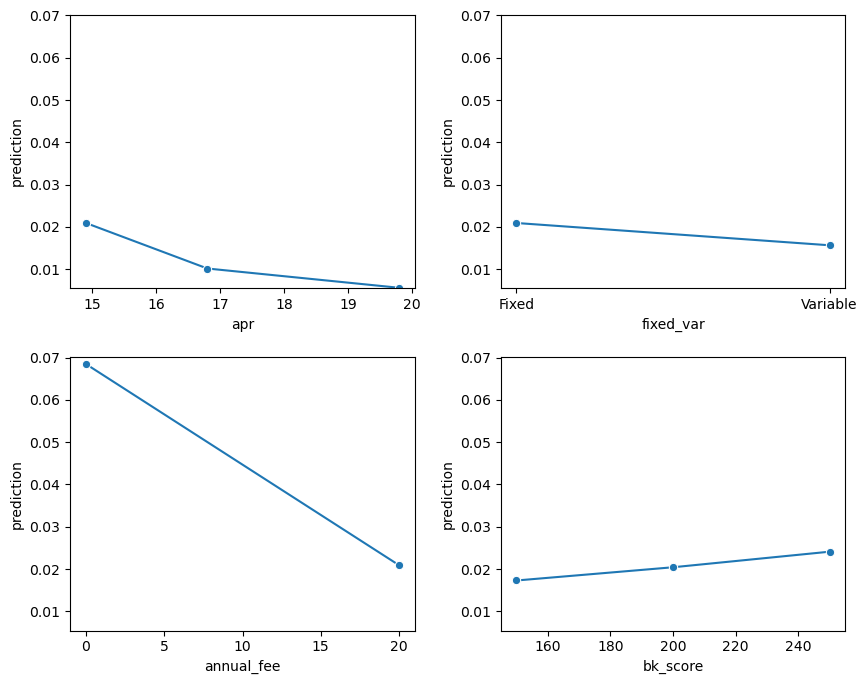

In [103]:
lr1.plot(plots="pred")

In [104]:
dct2 = rsm.levels_list(data_melt_test[['apr', 'fixed_var', 'annual_fee', 'bk_score']])
dct2

{'apr': [14.9, 16.8, 19.8],
 'fixed_var': ['Fixed', 'Variable'],
 'annual_fee': [0, 20],
 'bk_score': [150, 200, 250]}

In [105]:
data_test_expand2 = rsm.expand_grid(dct2)
data_test_expand2

,apr,fixed_var,annual_fee,bk_score
0,14.9,Fixed,0,150
1,14.9,Fixed,0,200
2,14.9,Fixed,0,250
3,14.9,Fixed,20,150
4,14.9,Fixed,20,200
5,14.9,Fixed,20,250
6,14.9,Variable,0,150
7,14.9,Variable,0,200
8,14.9,Variable,0,250
9,14.9,Variable,20,150


Predictions on the test data

In [106]:
data_test_expand2["pred_all_test"] = lr_test.predict(data_test_expand2)["prediction"]
data_test_expand2

,apr,fixed_var,annual_fee,bk_score,pred_all_test
0,14.9,Fixed,0,150,0.042661
1,14.9,Fixed,0,200,0.057015
2,14.9,Fixed,0,250,0.075816
3,14.9,Fixed,20,150,0.012138
4,14.9,Fixed,20,200,0.016399
5,14.9,Fixed,20,250,0.022120
6,14.9,Variable,0,150,0.031341
7,14.9,Variable,0,200,0.042053
8,14.9,Variable,0,250,0.056215
9,14.9,Variable,20,150,0.008843


In [107]:
final_table = pd.merge(new_table, data_test_expand2, on = ['apr', 'fixed_var', 'annual_fee','bk_score'])
final_table

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit,pred_all_test
0,3,14.9,Fixed,0,52,32,2,250,0.078416,0.156832,0.075816
1,3,14.9,Fixed,0,52,32,2,200,0.067001,2.144024,0.057015
2,4,14.9,Variable,0,62,42,12,250,0.059515,0.714180,0.056215
3,3,14.9,Fixed,0,52,32,2,150,0.057144,2.971507,0.042661
4,4,14.9,Variable,0,62,42,12,200,0.050700,2.129401,0.042053
5,4,14.9,Variable,0,62,42,12,150,0.043131,2.674108,0.031341
6,7,16.8,Fixed,0,72,52,22,250,0.039205,0.862512,0.028820
7,7,16.8,Fixed,0,72,52,22,200,0.033292,1.731173,0.021403
8,8,16.8,Variable,0,82,62,32,250,0.029453,0.942507,0.021092
9,7,16.8,Fixed,0,72,52,22,150,0.028244,2.033581,0.015864


## Compare the prediction

In [108]:
final_table['averge_pred_score'] = (final_table['pred_all'] + final_table['pred_all_test']) / 2

In [109]:
def calculate_clv_profit(row):
    # Mapping bk_score to clv column name
    clv_column = f"clv{int(row['bk_score'])}"
    # Returning the calculated clv_profit
    return row[clv_column] * row['pred_all_test'] if clv_column in row else 0

# Applying the function to each row of the DataFrame
final_table['clv_profit_test_prediction'] = final_table.apply(calculate_clv_profit, axis=1)

In [110]:
def calculate_clv_profit(row):
    # Mapping bk_score to clv column name
    clv_column = f"clv{int(row['bk_score'])}"
    # Returning the calculated clv_profit
    return row[clv_column] * row['averge_pred_score'] if clv_column in row else 0

# Applying the function to each row of the DataFrame
final_table['clv_profit_average_prediction'] = final_table.apply(calculate_clv_profit, axis=1)

In [111]:
final_table

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit,pred_all_test,averge_pred_score,clv_profit_test_prediction,clv_profit_average_prediction
0,3,14.9,Fixed,0,52,32,2,250,0.078416,0.156832,0.075816,0.077116,0.151632,0.154232
1,3,14.9,Fixed,0,52,32,2,200,0.067001,2.144024,0.057015,0.062008,1.824467,1.984245
2,4,14.9,Variable,0,62,42,12,250,0.059515,0.714180,0.056215,0.057865,0.674582,0.694381
3,3,14.9,Fixed,0,52,32,2,150,0.057144,2.971507,0.042661,0.049902,2.218347,2.594927
4,4,14.9,Variable,0,62,42,12,200,0.050700,2.129401,0.042053,0.046377,1.766242,1.947822
5,4,14.9,Variable,0,62,42,12,150,0.043131,2.674108,0.031341,0.037236,1.943129,2.308619
6,7,16.8,Fixed,0,72,52,22,250,0.039205,0.862512,0.028820,0.034012,0.634031,0.748271
7,7,16.8,Fixed,0,72,52,22,200,0.033292,1.731173,0.021403,0.027347,1.112946,1.422060
8,8,16.8,Variable,0,82,62,32,250,0.029453,0.942507,0.021092,0.025272,0.674929,0.808718
9,7,16.8,Fixed,0,72,52,22,150,0.028244,2.033581,0.015864,0.022054,1.142178,1.587879


In [112]:
final_table_sort = final_table.sort_values('pred_all_test', ascending=False)
final_table_sort

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit,pred_all_test,averge_pred_score,clv_profit_test_prediction,clv_profit_average_prediction
0,3,14.9,Fixed,0,52,32,2,250,0.078416,0.156832,0.075816,0.077116,0.151632,0.154232
1,3,14.9,Fixed,0,52,32,2,200,0.067001,2.144024,0.057015,0.062008,1.824467,1.984245
2,4,14.9,Variable,0,62,42,12,250,0.059515,0.714180,0.056215,0.057865,0.674582,0.694381
3,3,14.9,Fixed,0,52,32,2,150,0.057144,2.971507,0.042661,0.049902,2.218347,2.594927
4,4,14.9,Variable,0,62,42,12,200,0.050700,2.129401,0.042053,0.046377,1.766242,1.947822
5,4,14.9,Variable,0,62,42,12,150,0.043131,2.674108,0.031341,0.037236,1.943129,2.308619
6,7,16.8,Fixed,0,72,52,22,250,0.039205,0.862512,0.028820,0.034012,0.634031,0.748271
11,1,14.9,Fixed,20,83,63,33,250,0.024103,0.795386,0.022120,0.023111,0.729972,0.762679
12,11,19.8,Fixed,0,100,80,50,250,0.021859,1.092964,0.021911,0.021885,1.095546,1.094255
7,7,16.8,Fixed,0,72,52,22,200,0.033292,1.731173,0.021403,0.027347,1.112946,1.422060


In [113]:
final_table2 = final_table[['apr', 'fixed_var', 'annual_fee', 'clv_profit','bk_score', 'clv_profit_test_prediction', 'clv_profit_average_prediction']]
final_table2.to_csv('clv.csv')

#### Selecting the best Products for Bk Score 150

In [114]:
final_table_150 = final_table[final_table['bk_score'] == 150]
final_table_150_sorted = final_table_150.sort_values('clv_profit_average_prediction', ascending=False)
final_table_150_sorted

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit,pred_all_test,averge_pred_score,clv_profit_test_prediction,clv_profit_average_prediction
3,3,14.9,Fixed,0,52,32,2,150,0.057144,2.971507,0.042661,0.049902,2.218347,2.594927
5,4,14.9,Variable,0,62,42,12,150,0.043131,2.674108,0.031341,0.037236,1.943129,2.308619
9,7,16.8,Fixed,0,72,52,22,150,0.028244,2.033581,0.015864,0.022054,1.142178,1.587879
19,11,19.8,Fixed,0,100,80,50,150,0.015669,1.566880,0.012022,0.013846,1.202230,1.384555
13,8,16.8,Variable,0,82,62,32,150,0.021159,1.735019,0.011568,0.016364,0.948604,1.341812
17,1,14.9,Fixed,20,83,63,33,150,0.017288,1.434908,0.012138,0.014713,1.007487,1.221198
24,12,19.8,Variable,0,110,90,60,150,0.011700,1.287012,0.008758,0.010229,0.963367,1.125189
22,2,14.9,Variable,20,93,73,43,150,0.012915,1.201058,0.008843,0.010879,0.822374,1.011716
27,5,16.8,Fixed,20,103,83,53,150,0.008366,0.861692,0.004425,0.006396,0.455787,0.658739
30,6,16.8,Variable,20,113,93,63,150,0.006235,0.704582,0.003217,0.004726,0.363504,0.534043


We pick the best 2 products using expected CLV.

In [115]:
final_table_150_sorted[['offer', 'apr', 'fixed_var', 'annual_fee', 'clv_profit_average_prediction']].head(2)

,offer,apr,fixed_var,annual_fee,clv_profit_average_prediction
3,3,14.9,Fixed,0,2.594927
5,4,14.9,Variable,0,2.308619


In [116]:
row1_150 = final_table_150_sorted["clv_profit_average_prediction"].iloc[0]
row2_150 = final_table_150_sorted["clv_profit_average_prediction"].iloc[1]
tot_mails = 234844

comb1_150 = round((row1_150 / (row1_150 + row2_150))*tot_mails)
comb2_150 = round((row2_150 / (row1_150 + row2_150))*tot_mails)
print("Number of mails sent for Product combination 1 :", comb1_150)
print("Number of mails sent for Product combination 2 :", comb2_150)


Number of mails sent for Product combination 1 : 124278
Number of mails sent for Product combination 2 : 110566


#### Selecting the best Products for Bk Score 200

In [117]:
final_table_200 = final_table[final_table['bk_score'] == 200]
final_table_200_sorted = final_table_200.sort_values('clv_profit_average_prediction', ascending=False)
final_table_200_sorted

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit,pred_all_test,averge_pred_score,clv_profit_test_prediction,clv_profit_average_prediction
1,3,14.9,Fixed,0,52,32,2,200,0.067001,2.144024,0.057015,0.062008,1.824467,1.984245
4,4,14.9,Variable,0,62,42,12,200,0.050700,2.129401,0.042053,0.046377,1.766242,1.947822
7,7,16.8,Fixed,0,72,52,22,200,0.033292,1.731173,0.021403,0.027347,1.112946,1.422060
15,11,19.8,Fixed,0,100,80,50,200,0.018512,1.480947,0.016242,0.017377,1.299390,1.390169
10,8,16.8,Variable,0,82,62,32,200,0.024973,1.548306,0.015632,0.020302,0.969159,1.258732
14,1,14.9,Fixed,20,83,63,33,200,0.020419,1.286385,0.016399,0.018409,1.033108,1.159746
21,12,19.8,Variable,0,110,90,60,200,0.013833,1.244984,0.011846,0.012839,1.066123,1.155554
20,2,14.9,Variable,20,93,73,43,200,0.015266,1.114393,0.011960,0.013613,0.873096,0.993744
25,5,16.8,Fixed,20,103,83,53,200,0.009897,0.821470,0.005995,0.007946,0.497552,0.659511
31,9,19.8,Fixed,20,131,111,81,200,0.005445,0.604377,0.004532,0.004988,0.503056,0.553717


We pick the best 2 products using expected CLV.

In [118]:
final_table_200_sorted[['offer', 'apr', 'fixed_var', 'annual_fee', 'clv_profit_average_prediction']].head(2)

,offer,apr,fixed_var,annual_fee,clv_profit_average_prediction
1,3,14.9,Fixed,0,1.984245
4,4,14.9,Variable,0,1.947822


In [119]:
row1_200 = final_table_200_sorted["clv_profit_average_prediction"].iloc[0]
row2_200 = final_table_200_sorted["clv_profit_average_prediction"].iloc[1]
tot_mails = 234844

comb1_200 = round((row1_200 / (row1_200 + row2_200))*tot_mails)
comb2_200 = round((row2_200 / (row1_200 + row2_200))*tot_mails)
print("Number of mails sent for Product combination 1 :", comb1_200)
print("Number of mails sent for Product combination 2 :", comb2_200)

Number of mails sent for Product combination 1 : 118510
Number of mails sent for Product combination 2 : 116334


#### Selecting the best Products for Bk Score 250

In [120]:
final_table_250 = final_table[final_table['bk_score'] == 250]
final_table_250_sorted = final_table_250.sort_values('clv_profit_average_prediction', ascending=False)
final_table_250_sorted.head(6)

,offer,apr,fixed_var,annual_fee,clv150,clv200,clv250,bk_score,pred_all,clv_profit,pred_all_test,averge_pred_score,clv_profit_test_prediction,clv_profit_average_prediction
12,11,19.8,Fixed,0,100,80,50,250,0.021859,1.092964,0.021911,0.021885,1.095546,1.094255
18,12,19.8,Variable,0,110,90,60,250,0.016349,0.980920,0.016005,0.016177,0.960296,0.970608
8,8,16.8,Variable,0,82,62,32,250,0.029453,0.942507,0.021092,0.025272,0.674929,0.808718
11,1,14.9,Fixed,20,83,63,33,250,0.024103,0.795386,0.022120,0.023111,0.729972,0.762679
6,7,16.8,Fixed,0,72,52,22,250,0.039205,0.862512,0.028820,0.034012,0.634031,0.748271
16,2,14.9,Variable,20,93,73,43,250,0.018037,0.775586,0.016159,0.017098,0.694831,0.735208


We select the best 6 products using CLV profit average predictions. As the clv profit values are very close.

In [121]:
final_table_250_sorted[['offer', 'apr', 'fixed_var', 'annual_fee', 'clv_profit_average_prediction']].head(6)

,offer,apr,fixed_var,annual_fee,clv_profit_average_prediction
12,11,19.8,Fixed,0,1.094255
18,12,19.8,Variable,0,0.970608
8,8,16.8,Variable,0,0.808718
11,1,14.9,Fixed,20,0.762679
6,7,16.8,Fixed,0,0.748271
16,2,14.9,Variable,20,0.735208


In [122]:
row1_250 = final_table_250_sorted["clv_profit_average_prediction"].iloc[0]
row2_250 = final_table_250_sorted["clv_profit_average_prediction"].iloc[1]
row3_250 = final_table_250_sorted["clv_profit_average_prediction"].iloc[2]
row4_250 = final_table_250_sorted["clv_profit_average_prediction"].iloc[3]
row5_250 = final_table_250_sorted["clv_profit_average_prediction"].iloc[4]
row6_250 = final_table_250_sorted["clv_profit_average_prediction"].iloc[5]
tot_mails = 234844
sum_250 = row1_250 + row2_250 + row3_250 + row4_250 + row5_250 + row6_250
comb1_250 = round((row1_250 / sum_250)*tot_mails)
comb2_250 = round((row2_250 / sum_250)*tot_mails)
comb3_250 = round((row3_250 / sum_250)*tot_mails)
comb4_250 = round((row4_250 / sum_250)*tot_mails)
comb5_250 = round((row5_250 / sum_250)*tot_mails)
comb6_250 = round((row6_250 / sum_250)*tot_mails)

print("Number of mails sent for Product combination 1 :", comb1_200)
print("Number of mails sent for Product combination 2 :", comb2_250)
print("Number of mails sent for Product combination 3 :", comb1_250)
print("Number of mails sent for Product combination 4 :", comb2_250)
print("Number of mails sent for Product combination 5 :", comb1_250)
print("Number of mails sent for Product combination 6 :", comb2_250)

Number of mails sent for Product combination 1 : 118510
Number of mails sent for Product combination 2 : 44522
Number of mails sent for Product combination 3 : 50194
Number of mails sent for Product combination 4 : 44522
Number of mails sent for Product combination 5 : 50194
Number of mails sent for Product combination 6 : 44522


### Question 1 : Why does Customer Lifetime Value vary with BK score? Why does Customer Lifetime Value vary by product?

#### BK Score Effect
- Clear inverse relationship: as BK score ↑, CLV ↓
- Example (Product #1): BK 150: $83 → BK 200: $63 → BK 250: $33
- Consistent pattern: ~$20-30 decrease per 50-point BK increase
- Reason: Higher BK scores = higher default risk = lower lifetime value

- Higher BK scores (250) indicate lower credit risk, leading to higher CLV due to better retention and payment consistency.
- Lower BK scores (150) indicate higher risk, leading to lower CLV due to higher default rates and disengagement.
- CLV calculations in the dataset confirm that BK250 has the highest CLV, followed by BK200 and BK150.

#### Product Attribute Effects
##### APR Impact
- Higher APR → Higher CLV
- Calculation: From 14.9% to 19.8% (Fixed, $20 fee, BK 150)
- 14.9%: $83 → 16.8%: $103 → 19.8%: $131
- Rough formula: +$10 CLV per +1% APR

##### Annual Fee Impact
- With fee → Higher CLV
- Difference exceeds just the fee amount
- Example: $20 fee adds ~$30 to CLV (14.9% Fixed, BK 150)

##### Rate Type Impact
- Variable rate → +$10 CLV (consistent across all combinations)
- Protects margins when borrowing costs increase

These mathematical relationships inform which products maximize CLV for each segment.

- APR: Higher APR increases revenue but may reduce customer appeal.
- Fixed vs. Variable Rates: Fixed rates attract stability-seekers; variable rates appeal to cost-sensitive users.
- Annual Fees: Higher fees deter low-income customers but boost revenue from premium users.
- Key Insight: Products with lower APR and reasonable fees attract more customers, while products targeting higher BK scores yield higher CLV due to lower defaults and better retention.

### Question 2: Are predictive models estimated on historical data useful in this case? If so, why? If not, why not?

#### Why Historical Models Are Useful
- Initial Hypothesis Formation: Historical response rates (Exhibit 1) provide a foundational understanding of which product attributes are more favorable (e.g., fixed vs. variable rate preferences).
- Preliminary Parameter Estimation: Historical data helps in estimating the initial impact of different attributes on response rates, guiding the design of Round 1 testing.
- Risk Segmentation Validation: The data confirms that CLV varies systematically with BK score, supporting the chosen segmentation strategy.
#### Why Historical Models Alone Are Insufficient
- Limited Coverage of Combinations: Only 14 out of 36 possible product-BK score combinations were historically tested, leaving significant gaps.
- Market Evolution: Recent competitor campaigns and a >1 percentage point increase in interest rates have altered market conditions, making historical trends less reliable.
- Sparse Data in Key Segments: The BK 150 segment has limited historical observations (only 4 combinations), leading to weaker insights for that group.
- Complex Parameter Estimation: The number of parameters to estimate, including interaction effects, exceeds the available historical data points.
#### How We Addressed These Limitations
- Incorporating Test Data (Round 1 Results): We leveraged insights from Round 1 experiments to refine and validate model parameters, improving response rate predictions for Round 2.
- Adaptive Strategy: The combined use of historical data and real-world test data allowed us to update our approach, accounting for market shifts and previously untested product-BK combinations.
- Enhanced Predictive Accuracy: By integrating both data sources, we reduced estimation bias and improved confidence in our final Round 2 results.
- Thus, while historical models provided a valuable starting point, they were not sufficient alone. The inclusion of Round 1 test data was crucial for optimizing the final Round 2 strategy.

### Question 3: Is there a “best product” that will likely be preferred by all customers? If so, what is it?

Based on our predicted probabilities, all the customers from all segments (BK Score 150,200,250) is APR 14.9, Fixed_Var = Fixed, Annual_fee = 0. 
The predicted Probabilities are as follows:
- BK 150: 4.9%
- BK 200: 6.2%
- BK 250: 7.7%

These predicted probabilities indicate that, regardless of the BK score, customers are more likely to respond to this product offer. While products with higher fees or APR might yield higher individual CLV, the broad appeal of a no-fee, lower APR option increases the overall response rate, making it the most attractive choice for the entire customer base.

### Question 4: Describe and justify your testing strategy 

# Experiment Design
We chose a partial factorial design with 12 trials rather than a full design (36 trials) to limit the number of emails in our test phase and reduce costs. A full design would require substantially more emails, potentially inflating costs and cutting into overall profitability. In contrast, the partial design with 12 trials achieves a design efficiency of 0.892 and nearly zero correlation among factors, meaning we retain strong statistical power while testing fewer combinations.

To determine how many emails to send in each of these 12 trials, we used a sample size calculation to detect a difference between a 2% and 3% response rate. The result was approximately 3,789 emails per trial, giving us sufficient statistical precision without overspending on the test phase. This approach ensures we can distinguish meaningful performance differences among the credit card attributes (APR, annual fee, BK score, and fixed vs. variable rate) while staying within budget.

# Model Creation and CLV Calculation
We built an initial model using historical FiTech data (including APR, annual fee, BK score, and fixed vs. variable rate) to predict response rates. Multiplying predicted response rates by product-specific profitability estimates yielded an initial CLV (Customer Lifetime Value) for each product–segment combination.

After the test mailing, we updated the model with the new response data using the same explanatory variables, thus creating a second model more reflective of current market conditions. To finalize our predictions for the rollout, we averaged the CLV estimates from both models. This blended approach balances our prior knowledge with the latest insights, reducing the risk of relying solely on historical patterns or on a limited test sample.

# Rollout Selection
We then analyzed the combined (averaged) CLV estimates to decide which products to offer to each BK group:

BK 150: Two products stood out with significantly higher average CLV than the others, so we chose only those two.
BK 200: Similarly, we identified two clear winners with a notable CLV advantage, so we limited our offers to those two as well.
BK 250: Six products had CLVs so close that their differences fell within our margin of error. Rather than picking a single winner, we decided to hedge by allocating emails among the top six.
Within each BK group, we allocated emails proportionally to each product’s predicted CLV. This ensures that the product with the highest projected profitability gets the largest share, but other strong contenders also receive a meaningful allocation.

# Justification and Conclusion
By combining a partial factorial design with an appropriate sample size, we kept test costs manageable yet still gained sufficient data to distinguish performance. Averaging CLV estimates from both historical and test-phase models gave us robust predictions for the final rollout. For each BK group, we focused on top-performing products—either a few clear winners or a small set of similarly promising options. Finally, we used our entire database of 750,000 prospects because the projected incremental profit per email exceeded the variable cost of sending it, thereby maximizing overall profitability for FiTech.
